# Polynomial Regression

In [11]:
import numpy as np
import matplotlib.pyplot as plt

In [12]:
X = 6 * np.random.rand(200,1) - 3

# y = 0.8x^2 + 0.9x + 2
y = 0.8 * X**2 + 0.9 * X + 2 + np.random.randn(200,1)

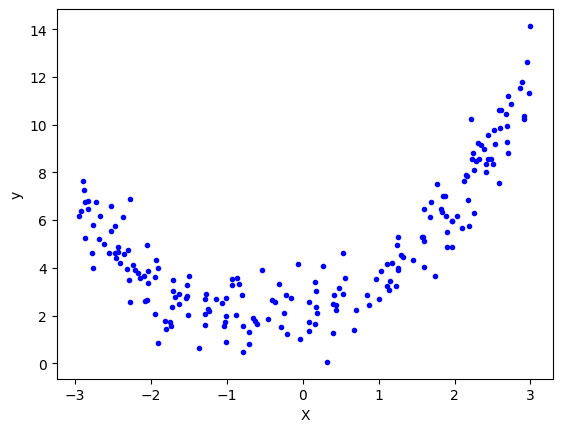

In [13]:
plt.plot(X,y,'b.')
plt.xlabel('X')
plt.ylabel('y')
plt.show()

In [14]:
# Train test split

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state  = 2)

In [15]:
# Applying Linear Regression

from sklearn.linear_model import LinearRegression

lr = LinearRegression()

In [16]:
lr.fit(X_train,y_train)

LinearRegression()

In [17]:
y_pred = lr.predict(X_test)


In [18]:
from sklearn.metrics import r2_score

r2_score(y_test,y_pred)

0.33187575237657263

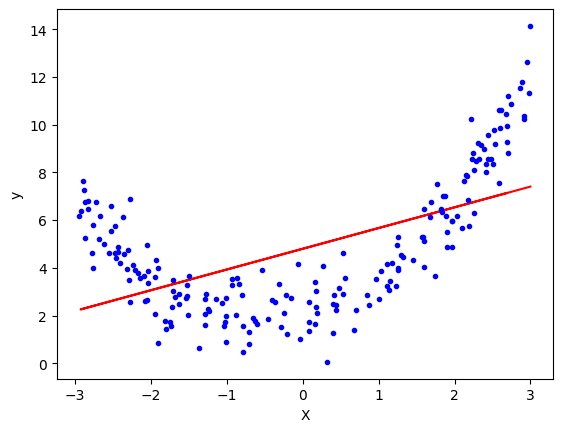

In [20]:
plt.plot(X_train,lr.predict(X_train),color = 'red')
plt.plot(X,y,'b.')
plt.xlabel('X')
plt.ylabel('y')
plt.show()

In [23]:
# Applying Polynomial Linear Regression
# degree 2

from sklearn.preprocessing import PolynomialFeatures,StandardScaler


poly = PolynomialFeatures(degree = 2,include_bias = True)

X_train_trans = poly.fit_transform(X_train)
X_test_trans = poly.fit_transform(X_test)



In [24]:
print(X_train[0])
print(X_train_trans[0])

[2.68890428]
[1.         2.68890428 7.23020622]


In [25]:
lr = LinearRegression()

lr.fit(X_train_trans,y_train)

LinearRegression()

In [26]:
y_pred = lr.predict(X_test_trans)

In [27]:
r2_score(y_test,y_pred)

0.8702295097629629

In [28]:
print(lr.coef_)
print(lr.intercept_)

[[0.         0.81551922 0.80661492]]
[2.01464203]


In [29]:
X_new=np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
y_new = lr.predict(X_new_poly)

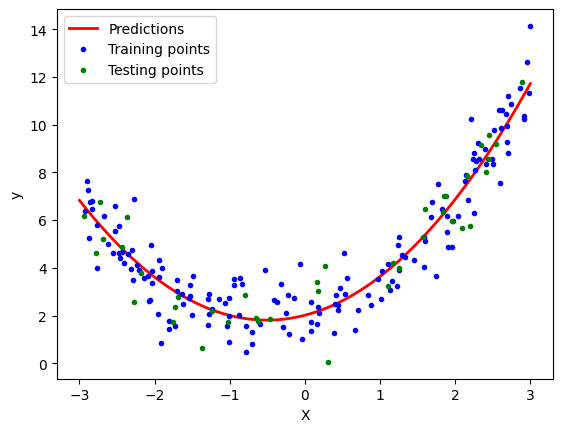

In [30]:
plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions")
plt.plot(X_train, y_train, "b.",label='Training points')
plt.plot(X_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


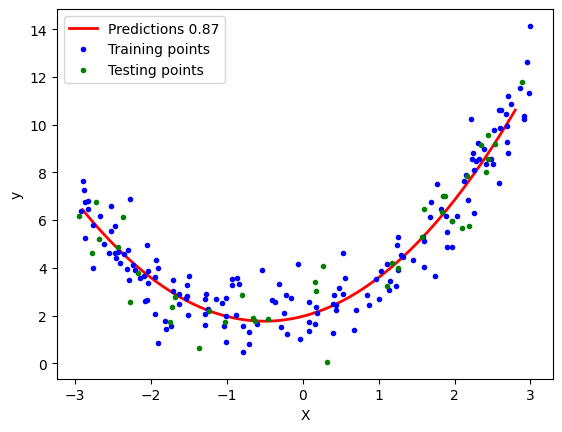

In [32]:
# Applying Gradient Descent

from sklearn.linear_model import SGDRegressor


poly = PolynomialFeatures(degree=2)

X_train_trans = poly.fit_transform(X_train)
X_test_trans = poly.transform(X_test)

sgd = SGDRegressor(max_iter=100)
sgd.fit(X_train_trans,y_train)

X_new=np.linspace(-2.9, 2.8, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
y_new = sgd.predict(X_new_poly)

y_pred = sgd.predict(X_test_trans)

plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions " + str(round(r2_score(y_test,y_pred),2)))
plt.plot(X_train, y_train, "b.",label='Training points')
plt.plot(X_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()


# **3D Polynomial Regression**

In [33]:
x = 7 * np.random.rand(100, 1) - 2.8

y = 7 * np.random.rand(100, 1) - 2.8

# z = x^2 + y^2 + 0.2x + 0.2y + 0.1xy + 2

z = x**2 + y**2 + 0.2*x + 0.2*y + 0.1*x*y +2 + np.random.randn(100, 1)


In [34]:
import plotly.express as px
df = px.data.iris()
fig = px.scatter_3d(df, x=x.ravel(), y=y.ravel(), z=z.ravel())
fig.show()

In [35]:
X_multi = np.array([x,y]).reshape(100,2)
X_multi.shape

(100, 2)

In [36]:
poly = PolynomialFeatures(degree=3)
X_multi_trans = poly.fit_transform(X_multi)

In [39]:
X_multi_trans.shape

(100, 10)

In [40]:
lr = LinearRegression()
lr.fit(X_multi_trans,z)

LinearRegression()

In [49]:
import plotly.graph_objects as go

# Create a meshgrid for the surface plot
x_input = np.linspace(x.min(), x.max(), 50)
y_input = np.linspace(y.min(), y.max(), 50)
x_grid, y_grid = np.meshgrid(x_input, y_input)

In [50]:
# Prepare the grid for polynomial transformation
xy_grid_combined = np.array([x_grid.ravel(), y_grid.ravel()]).T

In [51]:
# Transform the grid using the existing PolynomialFeatures object
poly = PolynomialFeatures(degree=3) # Re-initialize with the same degree as before
x_multi_trans_grid = poly.fit_transform(xy_grid_combined)

In [52]:
# Predict z values for the grid
z_final = lr.predict(x_multi_trans_grid).reshape(x_grid.shape)

fig = px.scatter_3d(x=x.ravel(), y=y.ravel(), z=z.ravel())

fig.add_trace(go.Surface(x = x_input, y = y_input, z =z_final))

fig.update_layout(scene = dict(zaxis = dict(range=[0,35])))

fig.show()